# Exploratory Data Analysis

This notebook documents the data-loading and leakage-removal steps used for the readmission model. It shows the target binarization, leaky discharge filtering, missing-value handling strategy, and the demographic features that later feed the bias audit.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
repo_root = Path.cwd()
for candidate in [repo_root, repo_root.parent, repo_root / '..']:
    candidate = candidate.resolve()
    if (candidate / 'data' / 'diabetic_data.csv').exists():
        repo_root = candidate
        break

data_path = repo_root / 'data' / 'diabetic_data.csv'
df = pd.read_csv(data_path)
print(f"Raw dataset shape: {df.shape}")
df.head()


C:\Users\obili\AppData\Local\Temp\ipykernel_30468\626376665.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Raw dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


target
0    0.888401
1    0.111599
Name: proportion, dtype: float64


C:\Users\obili\AppData\Local\Temp\ipykernel_30468\1509651030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, ax=ax, palette=['#7f8c8d', '#e67e22'])


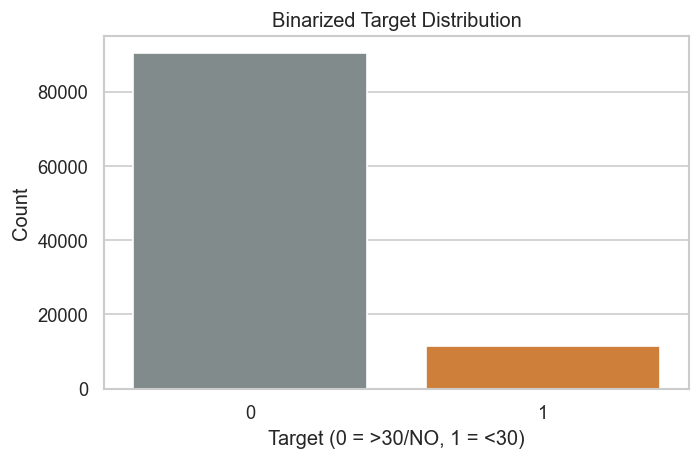

In [2]:
df['target'] = (df['readmitted'] == '<30').astype(int)
print(df['target'].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.countplot(x='target', data=df, ax=ax, palette=['#7f8c8d', '#e67e22'])
ax.set_title('Binarized Target Distribution')
ax.set_xlabel('Target (0 = >30/NO, 1 = <30)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


In [3]:
leakage_ids = [11, 13, 14, 19, 20, 21]
leakage_df = df[df['discharge_disposition_id'].isin(leakage_ids)]
df_clean = df[~df['discharge_disposition_id'].isin(leakage_ids)].copy()
print(f'Leaky rows removed: {len(leakage_df)}')
print(f'Clean dataset shape: {df_clean.shape}')

missing_cols = df_clean.replace('?', np.nan).isna().mean().sort_values(ascending=False)
print('\nTop missingness rates:')
print((missing_cols[missing_cols > 0] * 100).head(10).round(2))

for column in ['race', 'gender', 'age']:
    print(f'\n{column} distribution:')
    print(df_clean[column].value_counts(dropna=False).head(8))


Leaky rows removed: 2423
Clean dataset shape: (99343, 51)

Top missingness rates:
weight               96.85
max_glu_serum        94.81
A1Cresult            83.05
medical_specialty    48.94
payer_code           39.66
race                  2.25
diag_3                1.43
diag_2                0.36
diag_1                0.02
dtype: float64

race distribution:
race
Caucasian          74220
AfricanAmerican    18772
?                   2234
Hispanic            2017
Other               1472
Asian                628
Name: count, dtype: int64

gender distribution:
gender
Female             53454
Male               45886
Unknown/Invalid        3
Name: count, dtype: int64

age distribution:
age
[70-80)     25331
[60-70)     22059
[50-60)     17060
[80-90)     16434
[40-50)      9607
[30-40)      3764
[90-100)     2589
[20-30)      1649
Name: count, dtype: int64
